# 🎵 Decluttering Visualizations: Spotify Tracks Dataset
## *"Clutter Is Your Enemy"*

**Author:** Om Dipak Patil  
**Dataset:** Spotify Tracks Dataset (CSV)  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, WordCloud  
**Visualization Reference:** [datavizproject.com](https://datavizproject.com/)

---

## 1. Introduction

### What is the Dataset?

The **Spotify Tracks Dataset** contains audio features and metadata for over 114,000 tracks across 114 genres on Spotify. Each row represents a unique track with features such as popularity, danceability, energy, tempo, and explicit content flags.

### What is the Task?

This notebook demonstrates the principle **"Clutter Is Your Enemy"** in data visualization. For each topic:
- We first create a **cluttered version** — a visualization with too much noise, unnecessary elements, and poor design choices
- Then a **decluttered version** — a clean, focused chart that communicates the message clearly
- Finally, a **critical evaluation** explaining why the decluttered version is more effective

### Why Does Clutter Matter?

Visual clutter refers to any element in a chart that does not add informational value — excessive colors, heavy gridlines, too many categories, large markers, unnecessary labels, and busy backgrounds. Clutter:
- **Increases cognitive load** — the viewer works harder to extract the message
- **Hides patterns** — important trends get buried in noise
- **Misleads** — attention is drawn to irrelevant elements
- **Reduces trust** — poorly designed charts appear unprofessional

As Edward Tufte wrote: *"Above all else, show the data."* Every non-data element must justify its existence.

### Visualization Types Used

All visualizations in this notebook are types listed on **[datavizproject.com](https://datavizproject.com/)**:
- Histogram
- Bar Chart
- Scatter Plot
- Heatmap
- Box Plot
- Violin Plot
- Density Plot
- Word Cloud

---

## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Global style — will be overridden per chart to show cluttered vs clean
plt.rcParams['figure.dpi'] = 120

print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print("Libraries imported successfully! ")

Pandas  : 2.3.3
NumPy   : 2.3.5
Libraries imported successfully! 


---

## 3. Load and Clean the Dataset

In [2]:
df = pd.read_csv('dataset.csv', index_col=0)

print("Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nColumn Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (114000, 20)

First 5 Rows:
                 track_id                 artists  \
0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   
3  Can't Help Falling In Love        

In [3]:
# ── Data Cleaning ────────────────────────────────────────────────

# Drop missing rows (only 1 row)
df.dropna(inplace=True)

# Convert duration from ms to minutes
df['duration_min'] = df['duration_ms'] / 60000

# Remove duplicates
df.drop_duplicates(subset='track_id', inplace=True)

# Simplify artist names (first artist only)
df['artist_clean'] = df['artists'].str.split(';').str[0].str.strip()

# Explicit label
df['explicit_label'] = df['explicit'].map({True: 'Explicit', False: 'Non-Explicit'})

print(f"Cleaned dataset shape: {df.shape}")
print("\nSummary Statistics:")
print(df[['popularity','danceability','energy','duration_min','tempo']].describe().round(2))

Cleaned dataset shape: (89740, 23)

Summary Statistics:
       popularity  danceability    energy  duration_min     tempo
count    89740.00      89740.00  89740.00      89740.00  89740.00
mean        33.20          0.56      0.63          3.82    122.06
std         20.58          0.18      0.26          1.88     30.12
min          0.00          0.00      0.00          0.14      0.00
25%         19.00          0.45      0.46          2.88     99.26
50%         33.00          0.58      0.68          3.55    122.01
75%         49.00          0.69      0.85          4.40    140.08
max        100.00          0.98      1.00         87.29    243.37


---

# 4. Visualizations — Clutter vs Declutter

---

## 🔸 Visualization 1 — Popularity Distribution
### Type: Histogram *(datavizproject.com)*

A histogram shows the frequency distribution of a continuous variable. Here we analyze how track popularity is distributed across all Spotify tracks.

### ❌ Cluttered Version — Problems:
- Too many bins (100) making the chart noisy and jagged
- Every bar is a different random color — distracting with no meaning
- Heavy black gridlines compete with the data
- Thick black bar borders add visual noise
- Excessive tick marks on both axes

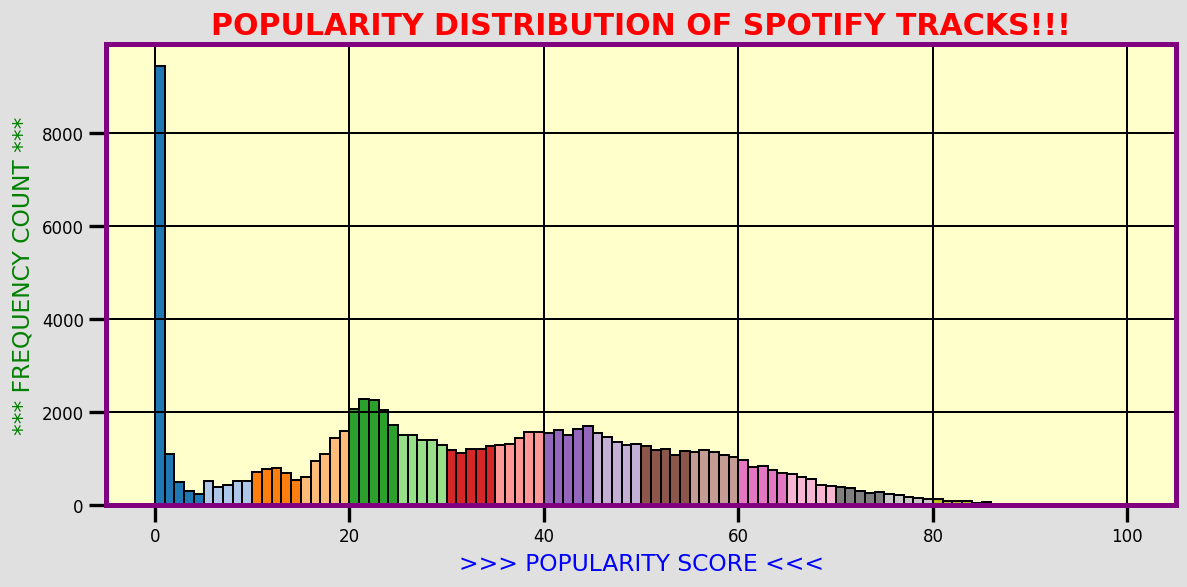

⚠️  CLUTTERED: 100 bins, 100 random colors, heavy borders, colored axes, yellow background


In [4]:
# ❌ CLUTTERED VERSION
fig, ax = plt.subplots(figsize=(10, 5))

colors = plt.cm.tab20(np.linspace(0, 1, 100))
n, bins, patches = ax.hist(df['popularity'], bins=100, edgecolor='black', linewidth=1.2)
for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

ax.set_title('POPULARITY DISTRIBUTION OF SPOTIFY TRACKS!!!',
             fontsize=18, fontweight='bold', color='red')
ax.set_xlabel('>>> POPULARITY SCORE <<<', fontsize=14, color='blue')
ax.set_ylabel('*** FREQUENCY COUNT ***', fontsize=14, color='green')
ax.grid(True, color='black', linewidth=1.2, linestyle='-')
ax.set_facecolor('#ffffcc')
fig.patch.set_facecolor('#e0e0e0')
ax.tick_params(axis='both', length=10, width=2)
for spine in ax.spines.values():
    spine.set_linewidth(3)
    spine.set_color('purple')

plt.tight_layout()
plt.show()
print("⚠️  CLUTTERED: 100 bins, 100 random colors, heavy borders, colored axes, yellow background")

### ✅ Decluttered Version — Improvements:
- Reduced to 30 bins — enough to show the shape without noise
- Single consistent color with subtle edge
- Light horizontal gridlines only (y-axis reference)
- Clean white background
- Median line added as a meaningful reference

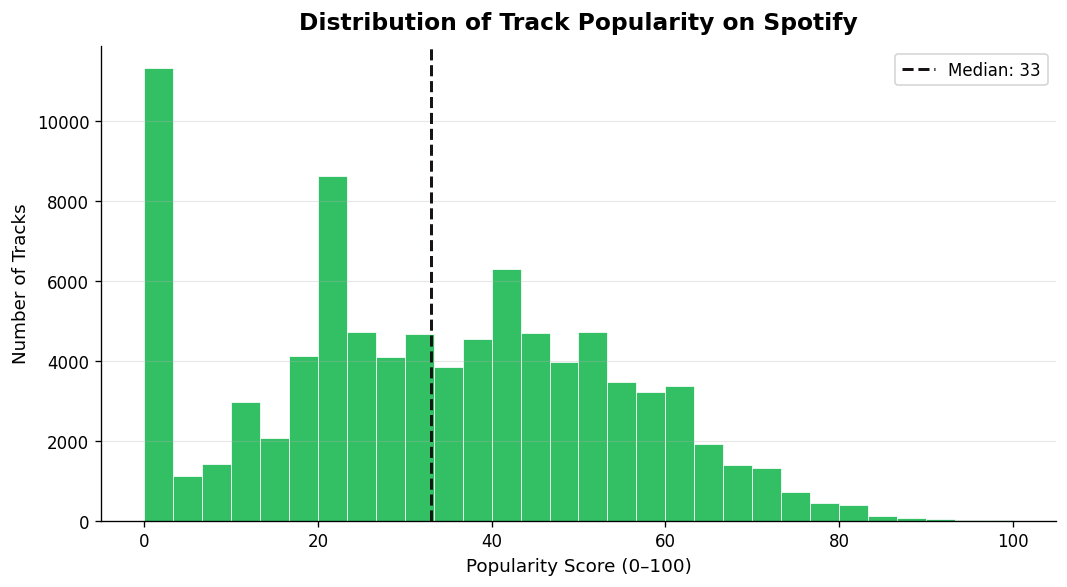

✅ DECLUTTERED: 30 bins, single color, subtle gridlines, clean background, median reference


In [6]:
# ✅ DECLUTTERED VERSION
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df['popularity'], bins=30, color='#1DB954',
        edgecolor='white', linewidth=0.5, alpha=0.9)
ax.axvline(df['popularity'].median(), color='#191414',
           linestyle='--', linewidth=1.8,
           label=f'Median: {df["popularity"].median():.0f}')

ax.set_title('Distribution of Track Popularity on Spotify', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Popularity Score (0–100)', fontsize=11)
ax.set_ylabel('Number of Tracks', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3, linewidth=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
sns.despine()

plt.tight_layout()
plt.savefig('viz1_popularity_histogram.png', dpi=150)
plt.show()
print("✅ DECLUTTERED: 30 bins, single color, subtle gridlines, clean background, median reference")

### 📝 Critical Evaluation — Visualization 1

| Element | Cluttered | Decluttered |
|---|---|---|
| Bins | 100 (jagged, noisy) | 30 (smooth shape) |
| Color | 100 random colors | 1 consistent green |
| Gridlines | Heavy black lines | Light y-axis only |
| Background | Yellow/grey | Clean white |
| Reference | None | Median line |

**Why the decluttered version is more effective:**  
The histogram's purpose is to show the **shape of the distribution**. Too many bins created a jagged, noisy chart where no pattern was visible. Random colors added zero information while maximally distracting. The decluttered version immediately reveals the right-skewed distribution — most tracks have low popularity, with a spike near 0. The median line provides a meaningful reference without adding clutter.

**Why histogram is the right type:**  
Popularity is a continuous numerical variable. A histogram is the standard and most effective chart for showing frequency distributions of continuous data — listed on [datavizproject.com](https://datavizproject.com/).

---

## 🔸 Visualization 2 — Genre Popularity
### Type: Bar Chart *(datavizproject.com)*

### ❌ Cluttered Version — Problems:
- All 114 genres plotted — impossible to read
- Random colors for every bar
- Vertical labels overlapping each other
- No clear ranking or focus

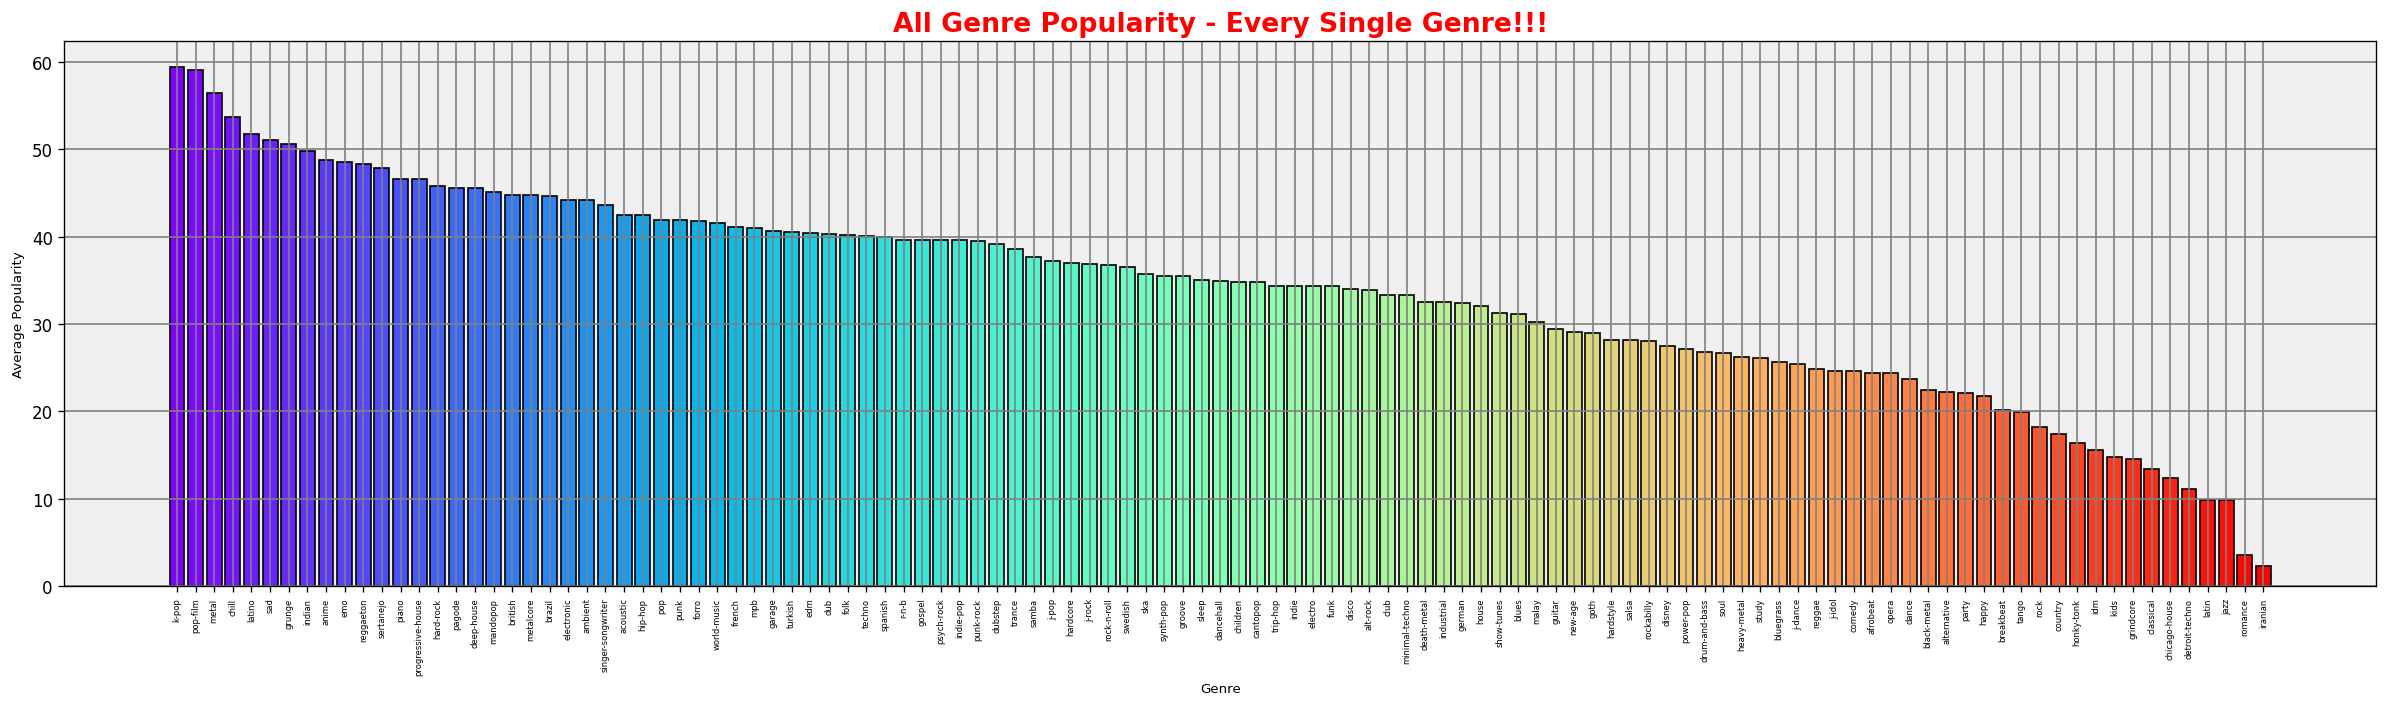

⚠️  CLUTTERED: All 114 genres, rainbow colors, illegible labels, grey background


In [7]:
# ❌ CLUTTERED VERSION
genre_pop_all = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(20, 6))
colors_all = plt.cm.rainbow(np.linspace(0, 1, len(genre_pop_all)))
ax.bar(genre_pop_all.index, genre_pop_all.values, color=colors_all, edgecolor='black')

ax.set_title('All Genre Popularity - Every Single Genre!!!', fontsize=16, fontweight='bold', color='red')
ax.set_xlabel('Genre', fontsize=8)
ax.set_ylabel('Average Popularity', fontsize=8)
ax.set_xticklabels(genre_pop_all.index, rotation=90, fontsize=5)
ax.grid(True, color='gray', linewidth=1)
ax.set_facecolor('#f0f0f0')

plt.tight_layout()
plt.show()
print("⚠️  CLUTTERED: All 114 genres, rainbow colors, illegible labels, grey background")

### ✅ Decluttered Version — Improvements:
- Only Top 10 genres shown
- Horizontal bars with readable labels
- Single color with top bar highlighted
- Sorted for immediate ranking

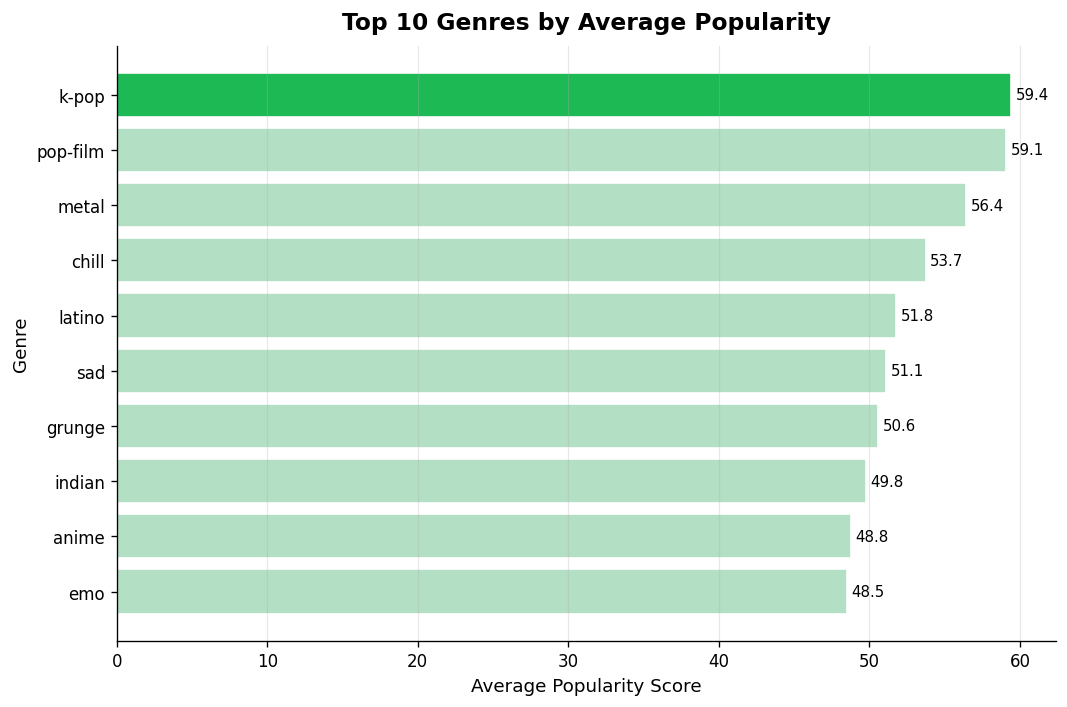

✅ DECLUTTERED: Top 10 only, horizontal bars, single color, top genre highlighted


In [8]:
# ✅ DECLUTTERED VERSION
top10_genres = genre_pop_all.head(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#1DB954' if i == len(top10_genres)-1 else '#b3dfc4'
          for i in range(len(top10_genres))]

bars = ax.barh(top10_genres.index, top10_genres.values,
               color=colors, edgecolor='white')

ax.set_title('Top 10 Genres by Average Popularity', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Average Popularity Score', fontsize=11)
ax.set_ylabel('Genre', fontsize=11)
ax.grid(True, axis='x', alpha=0.3, linewidth=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz2_genre_popularity.png', dpi=150)
plt.show()
print("✅ DECLUTTERED: Top 10 only, horizontal bars, single color, top genre highlighted")

### 📝 Critical Evaluation — Visualization 2

| Element | Cluttered | Decluttered |
|---|---|---|
| Categories | All 114 genres | Top 10 only |
| Orientation | Vertical (cramped) | Horizontal (readable) |
| Color | Rainbow (114 colors) | 2 shades of green |
| Labels | Rotated 90°, overlapping | Clear horizontal labels |
| Ranking | Hard to discern | Immediately visible |

**Why the decluttered version is more effective:**  
Showing all 114 genres made individual bars less than 5px wide — completely unreadable. The horizontal bar chart solves the label problem and allows natural reading from top to bottom. Limiting to Top 10 focuses attention on what matters most: which genres are most popular. The highlighted top bar draws the eye to the winner without needing to scan the whole chart.

---

## 🔸 Visualization 3 — Energy vs Danceability
### Type: Scatter Plot *(datavizproject.com)*

### ❌ Cluttered Version — Problems:
- 100,000+ points with no transparency — completely overplotted
- Large marker size blocks all patterns
- Multiple strong colors with no clear grouping
- Heavy gridlines compete with data

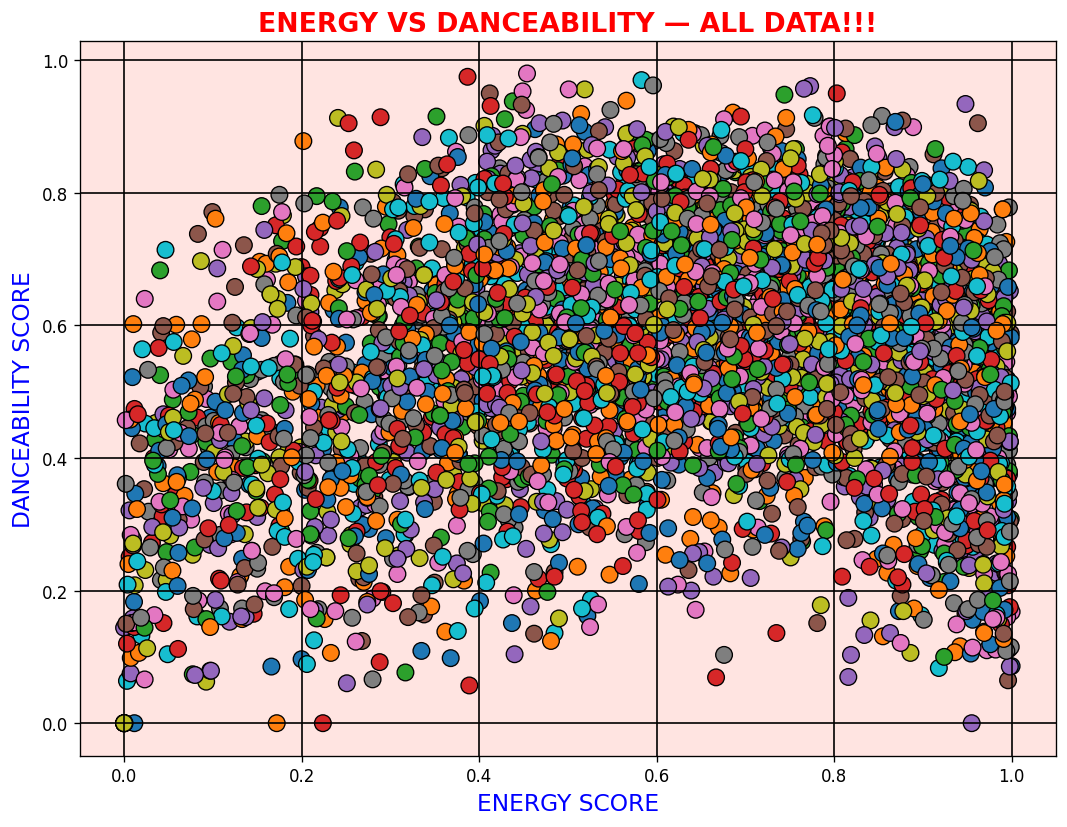

⚠️  CLUTTERED: Large opaque markers, random 10 colors, black borders, pink background, heavy grid


In [9]:
# ❌ CLUTTERED VERSION
sample = df.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(sample['energy'], sample['danceability'],
           c=np.random.randint(0, 10, len(sample)),
           cmap='tab10', s=100, edgecolors='black', linewidths=0.8)

ax.set_title('ENERGY VS DANCEABILITY — ALL DATA!!!', fontsize=16, color='red', fontweight='bold')
ax.set_xlabel('ENERGY SCORE', fontsize=14, color='blue')
ax.set_ylabel('DANCEABILITY SCORE', fontsize=14, color='blue')
ax.grid(True, color='black', linewidth=1.0)
ax.set_facecolor('#ffe4e1')

plt.tight_layout()
plt.show()
print("⚠️  CLUTTERED: Large opaque markers, random 10 colors, black borders, pink background, heavy grid")

### ✅ Decluttered Version — Improvements:
- Alpha transparency reveals density
- Small markers reduce overlap
- Single color with clean background
- Trend line added to show the relationship

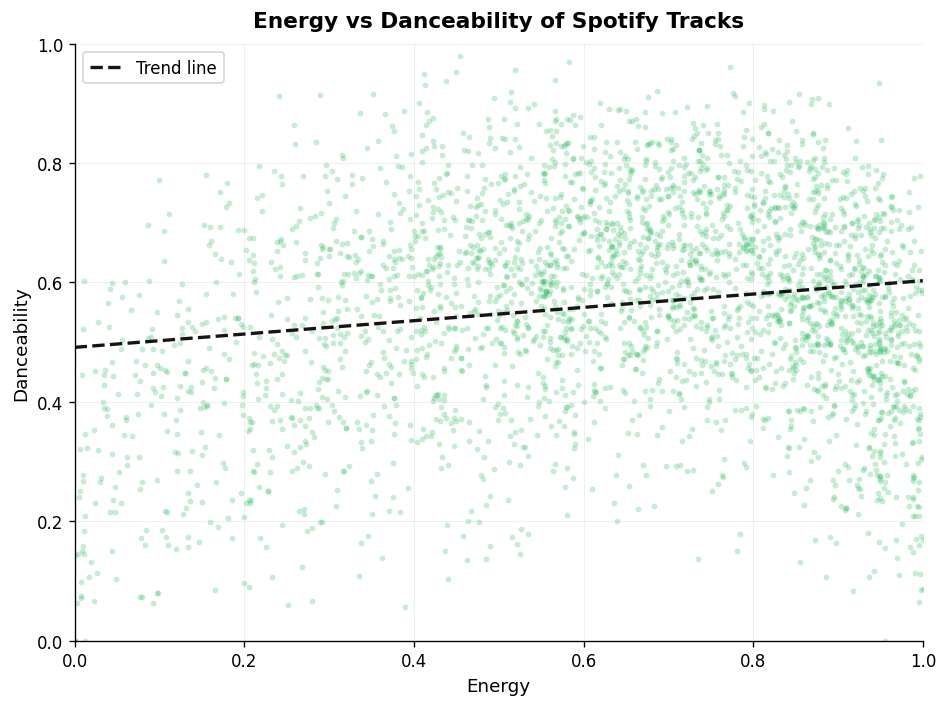

✅ DECLUTTERED: Small markers, alpha=0.25, single color, trend line, clean axes


In [10]:
# ✅ DECLUTTERED VERSION
sample = df.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(sample['energy'], sample['danceability'],
           color='#1DB954', s=12, alpha=0.25, linewidths=0)

# Add trend line
z = np.polyfit(sample['energy'], sample['danceability'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 1, 100)
ax.plot(x_line, p(x_line), color='#191414', linewidth=2,
        linestyle='--', label='Trend line')

ax.set_title('Energy vs Danceability of Spotify Tracks', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Energy', fontsize=11)
ax.set_ylabel('Danceability', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2, linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz3_scatter.png', dpi=150)
plt.show()
print("✅ DECLUTTERED: Small markers, alpha=0.25, single color, trend line, clean axes")

### 📝 Critical Evaluation — Visualization 3

| Element | Cluttered | Decluttered |
|---|---|---|
| Marker size | 100px (large) | 12px (small) |
| Transparency | 0% (opaque) | 75% (alpha=0.25) |
| Color | 10 random colors | 1 Spotify green |
| Background | Pink | White |
| Pattern | Hidden by overplot | Visible density clusters |

**Why the decluttered version is more effective:**  
With 100,000+ data points, overplotting (points covering each other) is the primary enemy. Transparency (alpha) converts the solid wall of color into a **density map** — darker areas indicate where most tracks cluster. Small markers reduce overlap. The trend line immediately communicates the weak positive relationship between energy and danceability without requiring the viewer to mentally estimate it.

---

## 🔸 Visualization 4 — Top Artists by Number of Tracks
### Type: Bar Chart *(datavizproject.com)*

### ❌ Cluttered Version — Problems:
- All artists plotted (thousands of bars)
- Illegible x-axis labels
- No useful insight visible

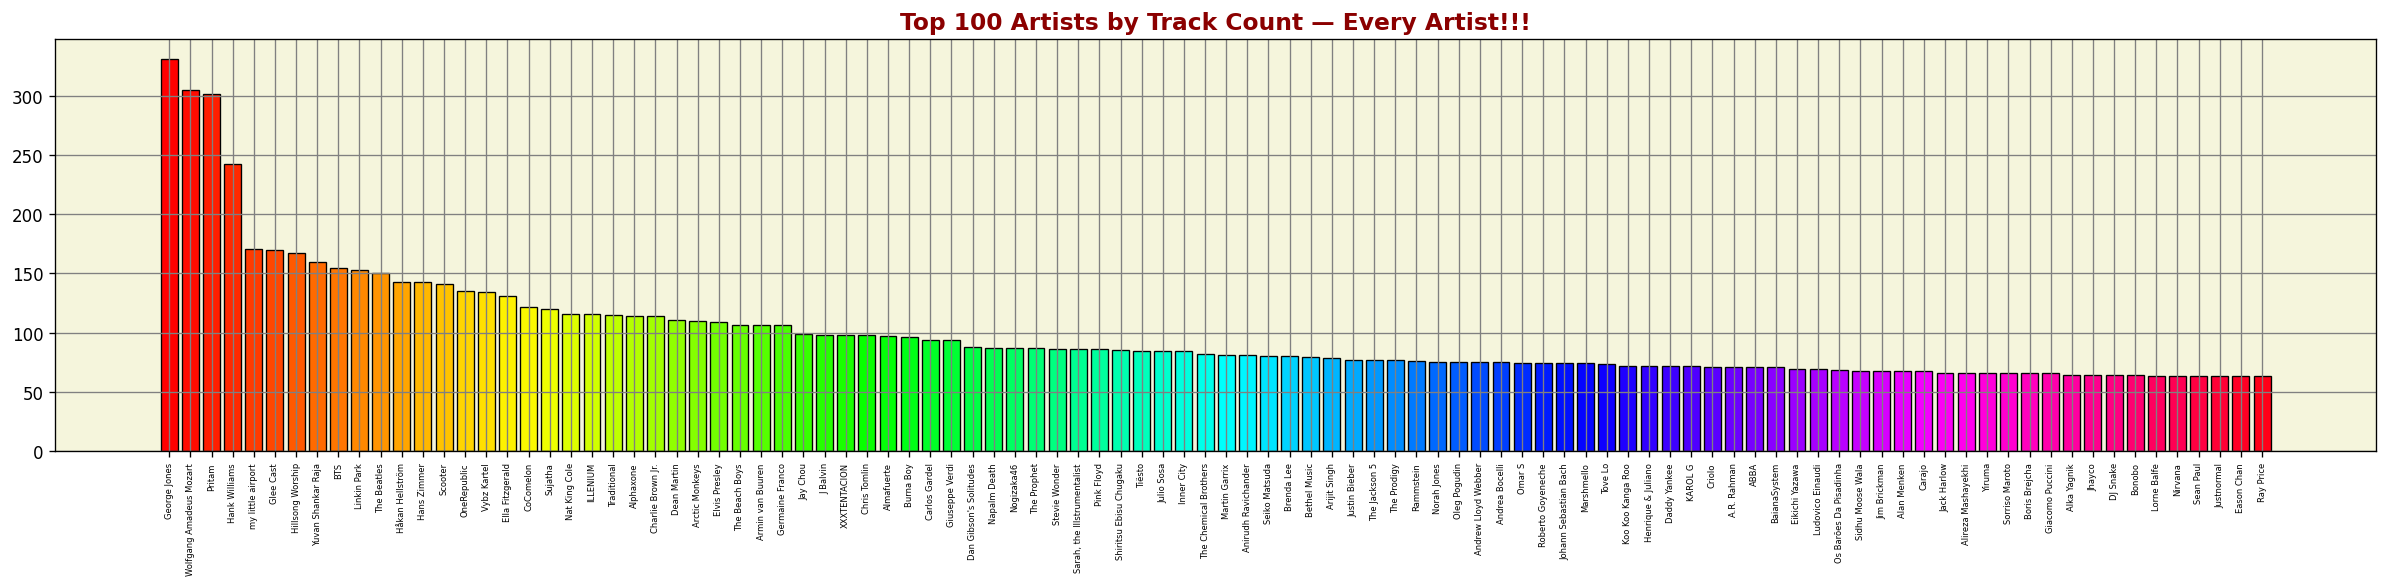

⚠️  CLUTTERED: 100 artists, rainbow colors, tiny labels, beige background


In [11]:
# ❌ CLUTTERED VERSION — top 100 already very cluttered
artist_counts_all = df['artist_clean'].value_counts().head(100)

fig, ax = plt.subplots(figsize=(20, 5))
colors_rand = plt.cm.hsv(np.linspace(0, 1, 100))
ax.bar(artist_counts_all.index, artist_counts_all.values,
       color=colors_rand, edgecolor='black', linewidth=0.8)

ax.set_title('Top 100 Artists by Track Count — Every Artist!!!',
             fontsize=14, color='darkred', fontweight='bold')
ax.set_xticklabels(artist_counts_all.index, rotation=90, fontsize=5)
ax.grid(True, color='grey', linewidth=0.8)
ax.set_facecolor('#f5f5dc')

plt.tight_layout()
plt.show()
print("⚠️  CLUTTERED: 100 artists, rainbow colors, tiny labels, beige background")

### ✅ Decluttered Version — Improvements:
- Only Top 15 artists
- Horizontal layout with clean labels
- Consistent color, top artist highlighted

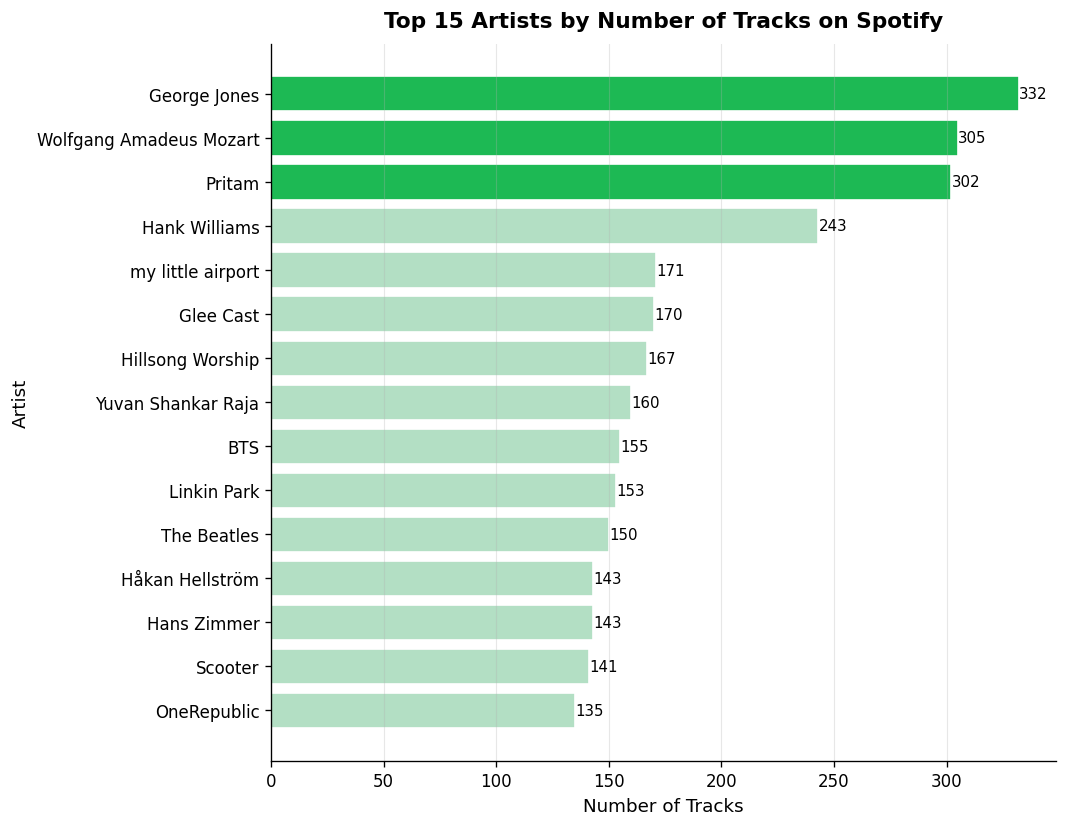

✅ DECLUTTERED: Top 15 only, horizontal, consistent color, top 3 highlighted


In [12]:
# ✅ DECLUTTERED VERSION
top15_artists = df['artist_clean'].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#1DB954' if i >= len(top15_artists)-3 else '#b3dfc4'
          for i in range(len(top15_artists))]

bars = ax.barh(top15_artists.index, top15_artists.values,
               color=colors, edgecolor='white')

ax.set_title('Top 15 Artists by Number of Tracks on Spotify',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Number of Tracks', fontsize=11)
ax.set_ylabel('Artist', fontsize=11)
ax.grid(True, axis='x', alpha=0.3, linewidth=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar in bars:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz4_top_artists.png', dpi=150)
plt.show()
print("✅ DECLUTTERED: Top 15 only, horizontal, consistent color, top 3 highlighted")

### 📝 Critical Evaluation — Visualization 4

| Element | Cluttered | Decluttered |
|---|---|---|
| Artists shown | 100 | 15 |
| Label readability | 5px rotated, overlapping | Clear, horizontal |
| Color | HSV rainbow | 2 greens |
| Insight visible | None | Top 3 clearly highlighted |

**Why the decluttered version is more effective:**  
Showing 100 artists created a chart where no individual bar was wide enough to read or compare. The principle of **selective filtering** — showing only what is relevant — dramatically improves the chart. The horizontal layout allows artist names to be read naturally. Highlighting the top 3 gives the viewer an immediate focal point.

---

## 🔸 Visualization 5 — Feature Correlation
### Type: Heatmap *(datavizproject.com)*

### ❌ Cluttered Version — Problems:
- Too many decimal places in annotations
- Harsh diverging color with too many ticks
- All features including weak/irrelevant ones

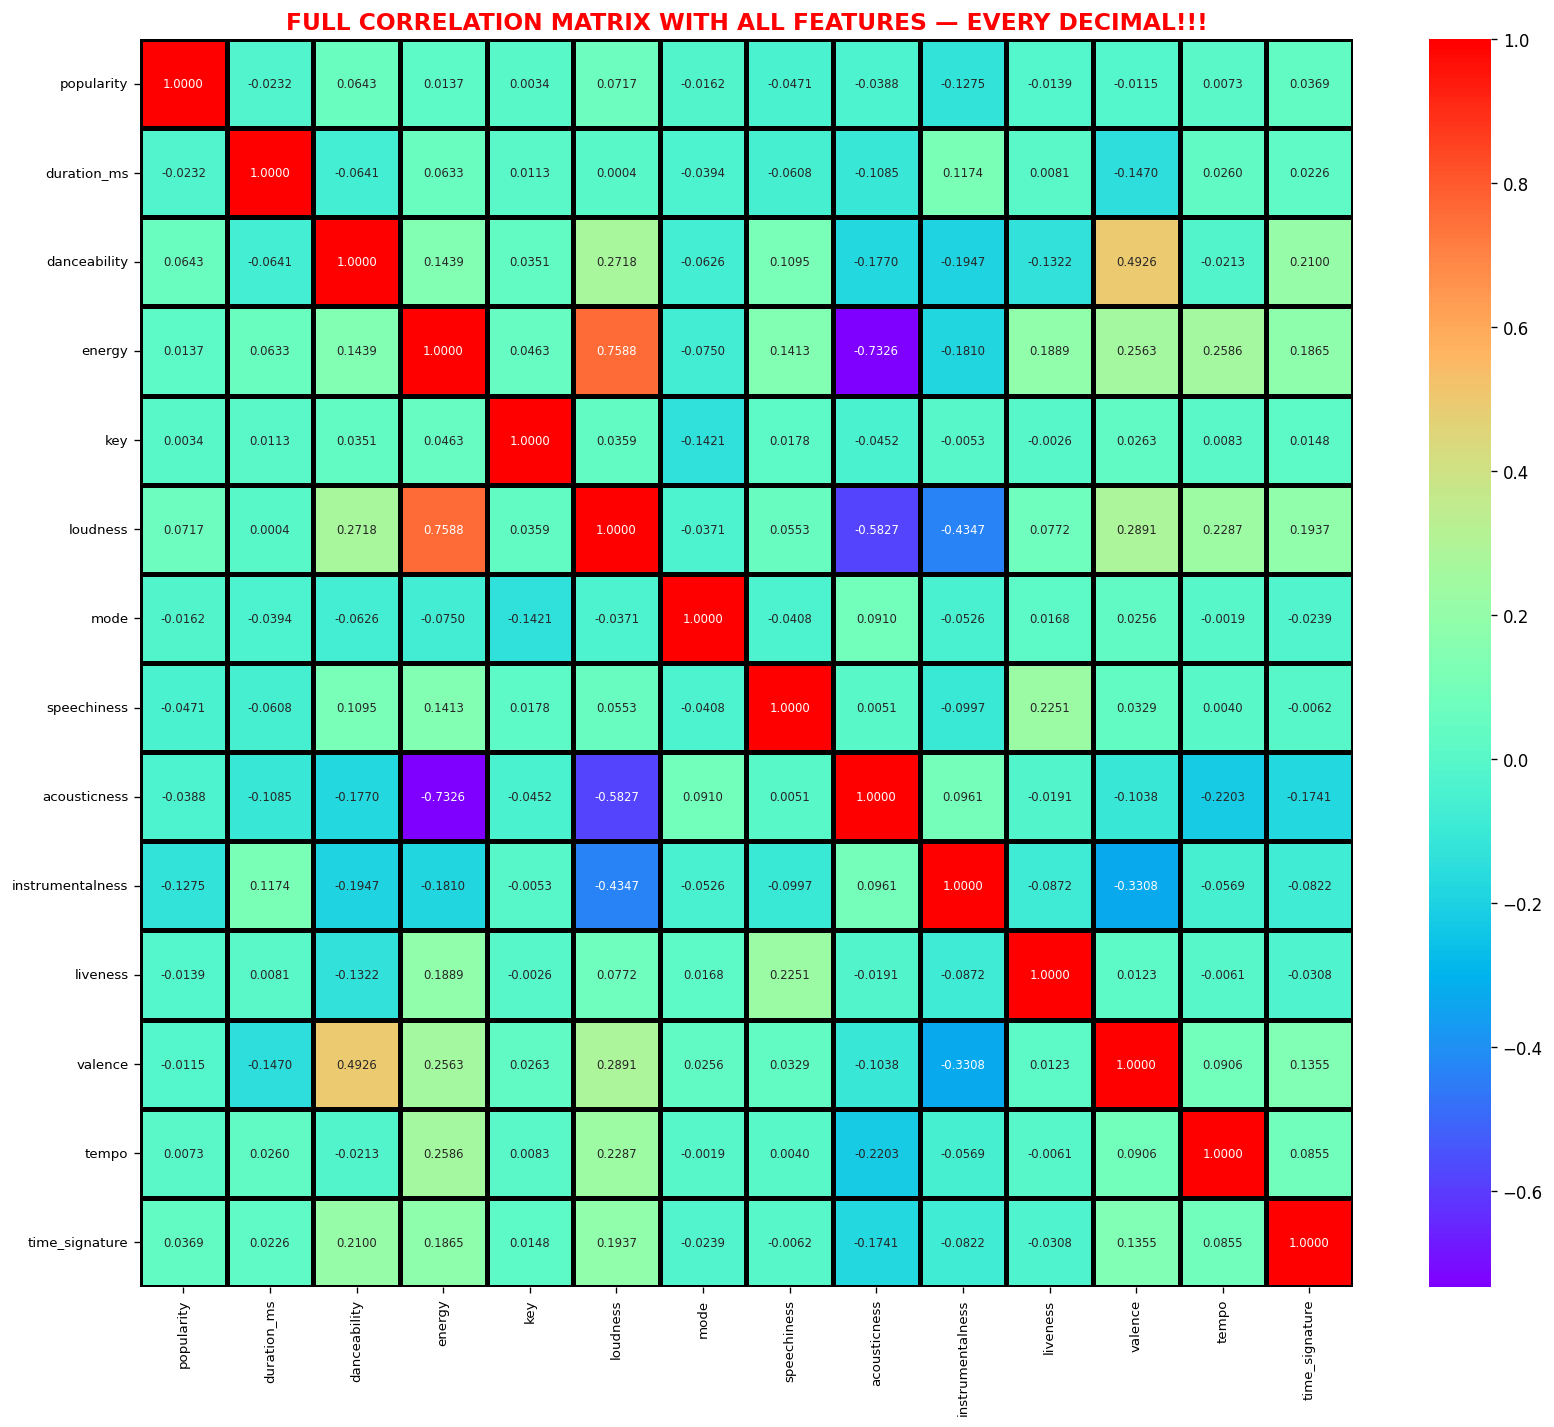

⚠️  CLUTTERED: 4 decimal places, rainbow cmap, black cell borders, all 14 features


In [13]:
# ❌ CLUTTERED VERSION
num_cols_all = ['popularity','duration_ms','danceability','energy','key',
                'loudness','mode','speechiness','acousticness',
                'instrumentalness','liveness','valence','tempo','time_signature']
corr_all = df[num_cols_all].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_all, annot=True, fmt='.4f', cmap='rainbow',
            linewidths=2, linecolor='black', ax=ax,
            annot_kws={'size': 7})
ax.set_title('FULL CORRELATION MATRIX WITH ALL FEATURES — EVERY DECIMAL!!!',
             fontsize=14, color='red', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()
print("⚠️  CLUTTERED: 4 decimal places, rainbow cmap, black cell borders, all 14 features")

### ✅ Decluttered Version — Improvements:
- Focused on 8 most meaningful features
- 2 decimal places only
- Clean diverging colormap (coolwarm)
- Masked upper triangle to remove redundancy

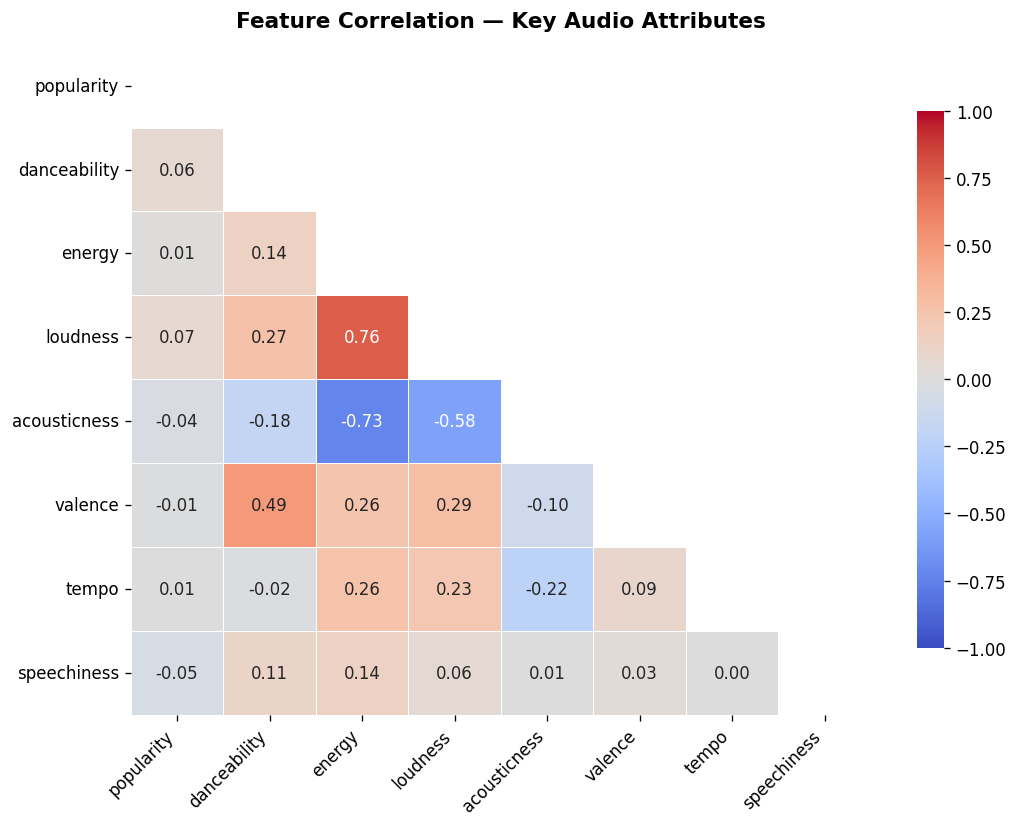

✅ DECLUTTERED: 8 key features, 2 decimals, triangle mask, coolwarm palette


In [14]:
# ✅ DECLUTTERED VERSION
key_cols = ['popularity','danceability','energy',
            'loudness','acousticness','valence','tempo','speechiness']
corr_clean = df[key_cols].corr()

# Mask upper triangle (redundant)
mask = np.triu(np.ones_like(corr_clean, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_clean, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor='white', ax=ax,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})

ax.set_title('Feature Correlation — Key Audio Attributes',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('viz5_heatmap.png', dpi=150)
plt.show()
print("✅ DECLUTTERED: 8 key features, 2 decimals, triangle mask, coolwarm palette")

### 📝 Critical Evaluation — Visualization 5

| Element | Cluttered | Decluttered |
|---|---|---|
| Features | 14 (all) | 8 (meaningful) |
| Annotations | 4 decimal places | 2 decimal places |
| Colormap | Rainbow (misleading) | Coolwarm (diverging, intuitive) |
| Cell borders | Thick black | Thin white |
| Redundancy | Full matrix (mirrored) | Triangle mask |

**Why the decluttered version is more effective:**  
A heatmap should tell the viewer which pairs of features are strongly related. Including all 14 features created a 14×14 matrix with 196 cells — far too much to process. The triangle mask removes the redundant mirrored half. Coolwarm is a **perceptually uniform** diverging palette — red means positive, blue means negative correlation, which is instantly interpretable. 4 decimal places of precision added false accuracy with no value.

---

## 🔸 Visualization 6 — Popularity by Explicit Content
### Type: Box Plot *(datavizproject.com)*

### ❌ Cluttered Version — Problems:
- Overly decorated with custom styles
- All outliers shown as large colored dots
- Busy background and extra annotations

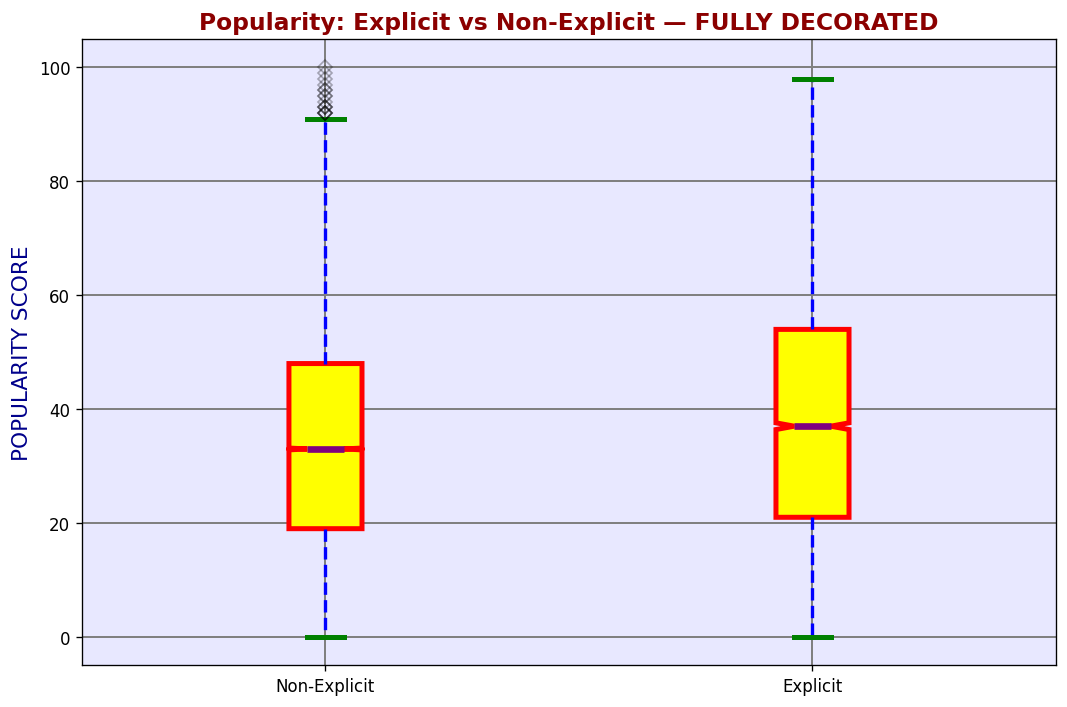

⚠️  CLUTTERED: Yellow box, red/blue/green borders, purple median, orange outliers, purple background


In [15]:
# ❌ CLUTTERED VERSION
fig, ax = plt.subplots(figsize=(9, 6))

groups = [df[df['explicit']==False]['popularity'].values,
          df[df['explicit']==True]['popularity'].values]

bp = ax.boxplot(groups, labels=['Non-Explicit', 'Explicit'],
                patch_artist=True, notch=True,
                boxprops=dict(facecolor='yellow', color='red', linewidth=3),
                whiskerprops=dict(color='blue', linewidth=2, linestyle='--'),
                capprops=dict(color='green', linewidth=3),
                medianprops=dict(color='purple', linewidth=4),
                flierprops=dict(marker='D', color='orange', markersize=6, alpha=0.3))

ax.set_title('Popularity: Explicit vs Non-Explicit — FULLY DECORATED',
             fontsize=14, color='darkred', fontweight='bold')
ax.set_facecolor('#e8e8ff')
ax.grid(True, color='gray', linewidth=1.2)
ax.set_ylabel('POPULARITY SCORE', fontsize=13, color='darkblue')

plt.tight_layout()
plt.show()
print("⚠️  CLUTTERED: Yellow box, red/blue/green borders, purple median, orange outliers, purple background")

### ✅ Decluttered Version — Improvements:
- Clean two-tone color scheme
- Outliers shown as small transparent dots
- Minimal decoration — data speaks for itself

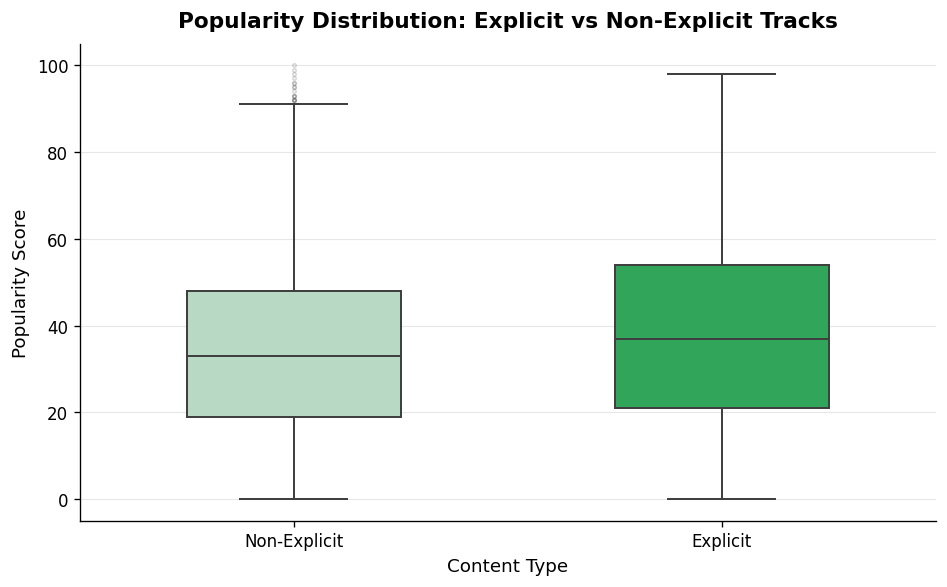

✅ DECLUTTERED: Two greens, small outliers, clean axes, subtitle removed


In [16]:
# ✅ DECLUTTERED VERSION
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df, x='explicit_label', y='popularity',
            palette={'Non-Explicit': '#b3dfc4', 'Explicit': '#1DB954'},
            order=['Non-Explicit', 'Explicit'],
            width=0.5, linewidth=1.2,
            flierprops=dict(marker='o', markersize=2, alpha=0.2, color='gray'),
            ax=ax)

ax.set_title('Popularity Distribution: Explicit vs Non-Explicit Tracks',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Content Type', fontsize=11)
ax.set_ylabel('Popularity Score', fontsize=11)
ax.grid(True, axis='y', alpha=0.3, linewidth=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz6_boxplot.png', dpi=150)
plt.show()
print("✅ DECLUTTERED: Two greens, small outliers, clean axes, subtitle removed")

### 📝 Critical Evaluation — Visualization 6

**Why the decluttered version is more effective:**  
The cluttered version used 5 different colors for different parts of the same box — this adds zero information while maximally confusing the viewer. A box plot already encodes several statistics (median, IQR, range, outliers) through position and shape — it needs no additional decoration. Clean, consistent colors help the viewer focus on the **comparison between the two groups** rather than the styling of the chart itself.

---

## 🔸 Visualization 7 — Energy Distribution
### Type: Violin Plot *(datavizproject.com)*

### ❌ Cluttered Version — Problems:
- All genres overlaid in one violin
- Too many colors with no legend
- Chart too wide and unreadable

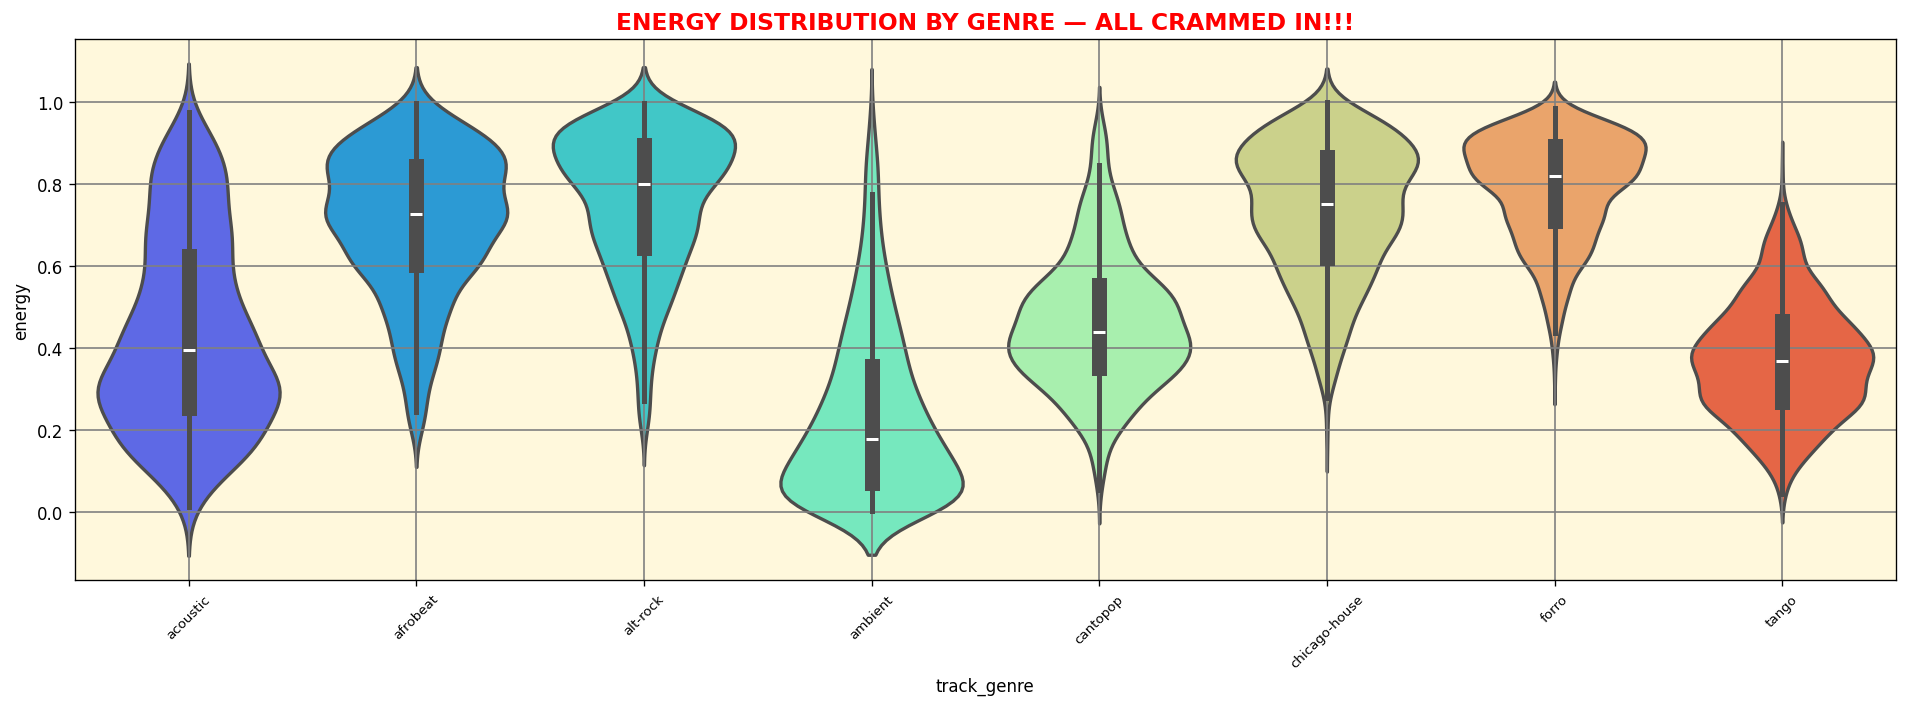

⚠️  CLUTTERED: 8 genres, rainbow colors, cramped layout, cream background


In [17]:
# ❌ CLUTTERED VERSION — top 10 genres already cluttered
top5_genres = df['track_genre'].value_counts().head(8).index.tolist()
df_top5 = df[df['track_genre'].isin(top5_genres)]

fig, ax = plt.subplots(figsize=(16, 6))
sns.violinplot(data=df_top5, x='track_genre', y='energy',
               palette='rainbow', ax=ax, linewidth=2)

ax.set_title('ENERGY DISTRIBUTION BY GENRE — ALL CRAMMED IN!!!',
             fontsize=14, color='red', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=8)
ax.set_facecolor('#fff8dc')
ax.grid(True, color='gray', linewidth=1)

plt.tight_layout()
plt.show()
print("⚠️  CLUTTERED: 8 genres, rainbow colors, cramped layout, cream background")

### ✅ Decluttered Version — Improvements:
- 5 contrasting genres for meaningful comparison
- Consistent palette, sorted by median
- Clean background, inner quartile box added

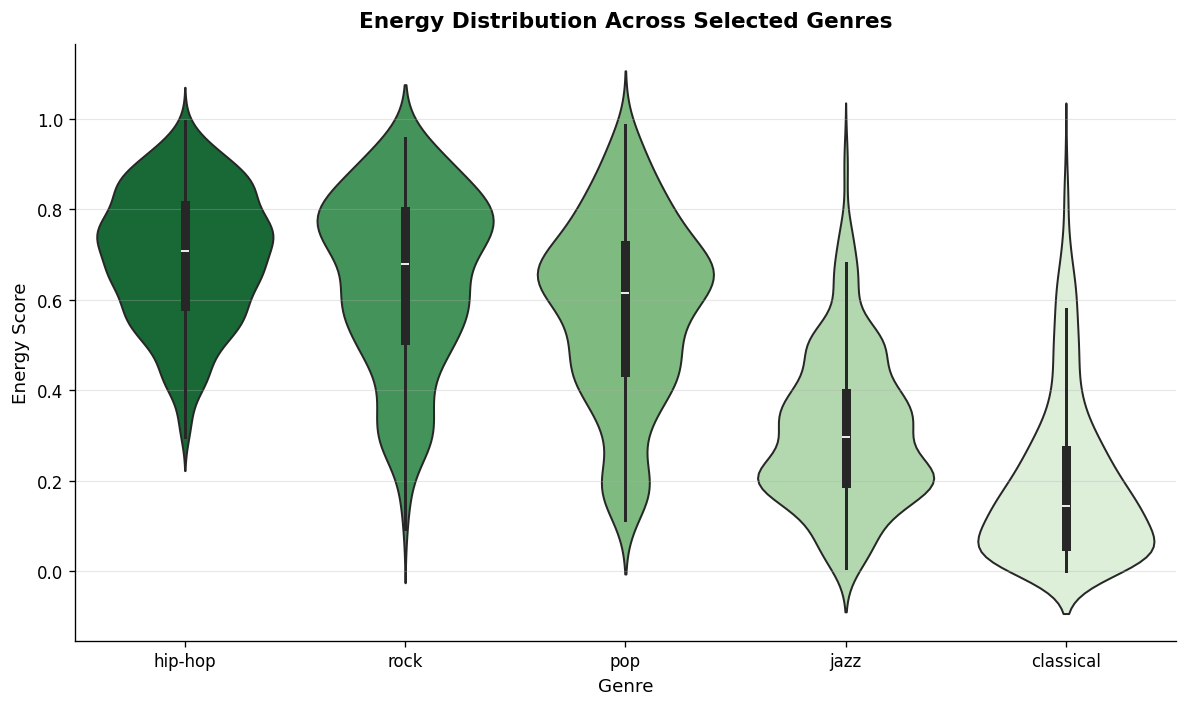

✅ DECLUTTERED: 5 meaningful genres, Greens palette, sorted by median, inner box


In [18]:
# ✅ DECLUTTERED VERSION
selected_genres = ['pop', 'rock', 'jazz', 'classical', 'hip-hop']
df_sel = df[df['track_genre'].isin(selected_genres)]

# Sort by median energy
order = df_sel.groupby('track_genre')['energy'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df_sel, x='track_genre', y='energy',
               order=order,
               palette='Greens_r',
               inner='box', linewidth=1.2, ax=ax)

ax.set_title('Energy Distribution Across Selected Genres',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Genre', fontsize=11)
ax.set_ylabel('Energy Score', fontsize=11)
ax.grid(True, axis='y', alpha=0.3, linewidth=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz7_violin.png', dpi=150)
plt.show()
print("✅ DECLUTTERED: 5 meaningful genres, Greens palette, sorted by median, inner box")

### 📝 Critical Evaluation — Visualization 7

**Why the decluttered version is more effective:**  
Violin plots combine a box plot with a density curve — they are already information-dense. Cramming 8+ genres makes each violin too narrow to read. Selecting 5 contrasting genres (pop, rock, jazz, classical, hip-hop) and sorting by median creates a clear **ranking of energy levels** across genre types. The `inner='box'` parameter adds the median and IQR reference within each violin without extra clutter.

---

## 🔸 Visualization 8 — Most Common Words in Track Names
### Type: Word Cloud *(datavizproject.com)*

### ❌ Cluttered Version — Problems:
- All words including stop words (the, a, of, in)
- Too many words (max_words=500)
- Harsh multi-color scheme

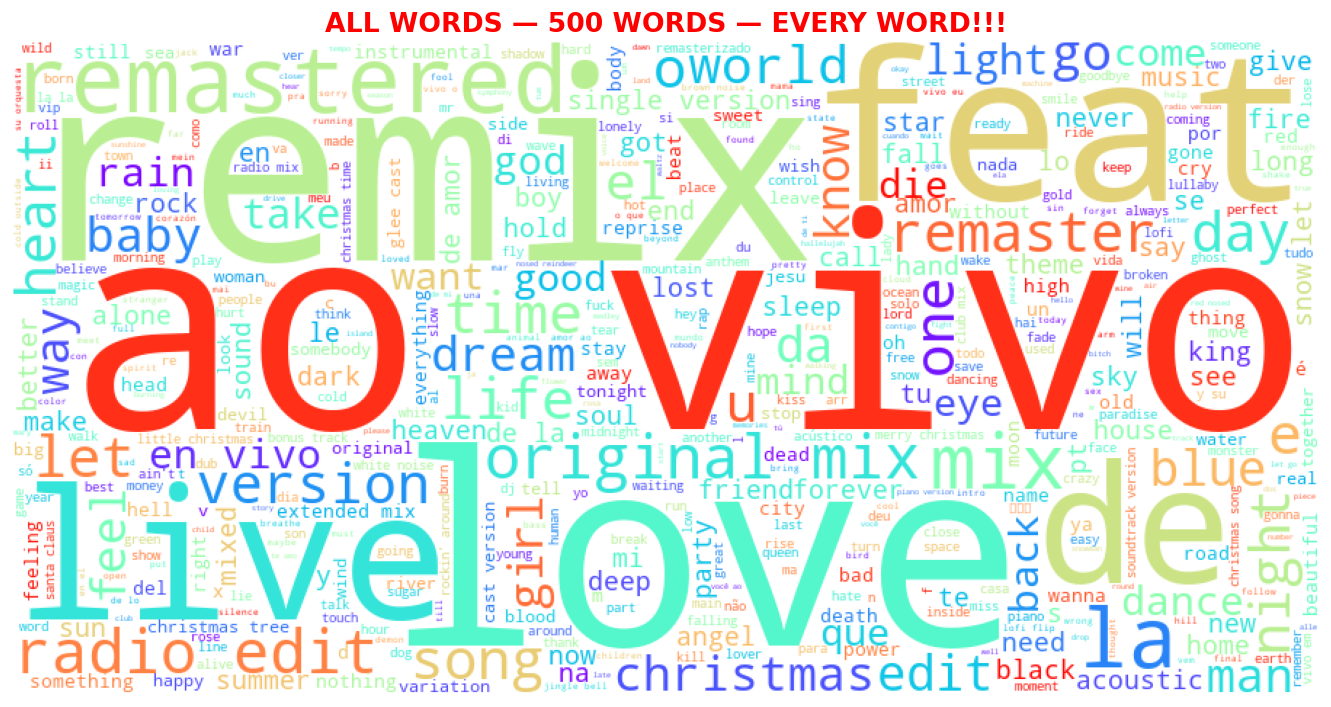

⚠️  CLUTTERED: 500 words, rainbow colors, stop words included, collocations=True


In [19]:
# ❌ CLUTTERED VERSION
all_words_messy = ' '.join(df['track_name'].dropna().str.lower().values)

wc_cluttered = WordCloud(
    width=900, height=450,
    background_color='white',
    max_words=500,
    colormap='rainbow',
    collocations=True
).generate(all_words_messy)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc_cluttered)
ax.axis('off')
ax.set_title('ALL WORDS — 500 WORDS — EVERY WORD!!!',
             fontsize=16, color='red', fontweight='bold')

plt.tight_layout()
plt.show()
print("⚠️  CLUTTERED: 500 words, rainbow colors, stop words included, collocations=True")

### ✅ Decluttered Version — Improvements:
- Stop words removed
- Max 80 meaningful words
- Single Spotify-themed color palette
- Dark background for contrast

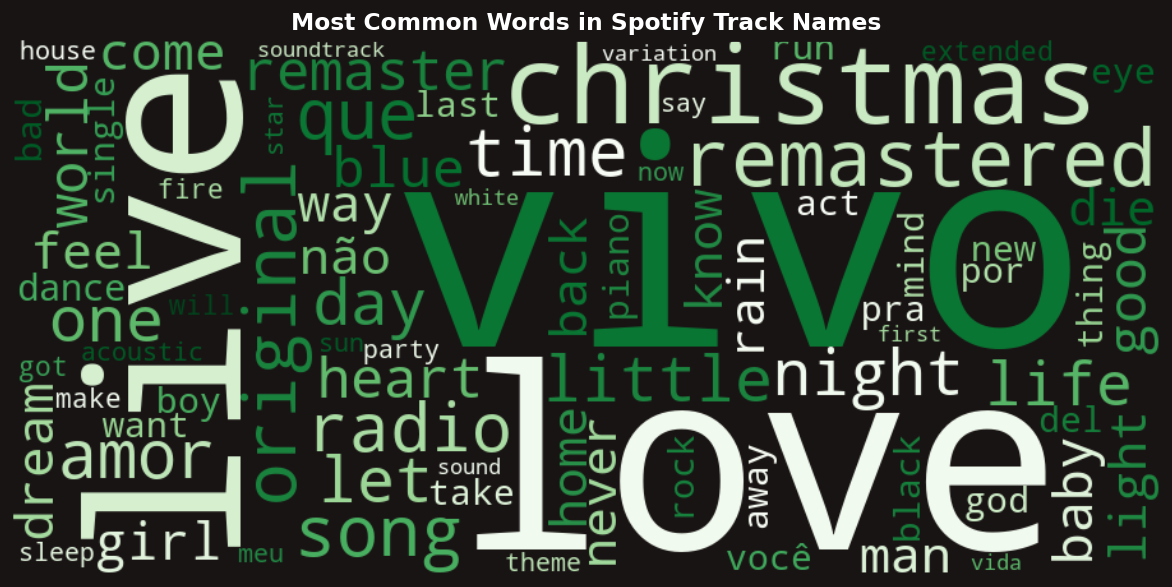

✅ DECLUTTERED: Stop words removed, 80 words, Greens palette, Spotify dark theme


In [20]:
# ✅ DECLUTTERED VERSION
stop_words = {'the','a','an','of','in','on','at','to','for','is','are',
              'was','it','i','my','you','your','me','we','be','with',
              'and','or','but','not','no','so','do','feat','remix',
              'version','edit','mix','from','by','ft'}

clean_words = ' '.join(
    word for title in df['track_name'].dropna().str.lower()
    for word in title.split()
    if word.isalpha() and word not in stop_words and len(word) > 2
)

wc_clean = WordCloud(
    width=900, height=420,
    background_color='#191414',
    colormap='Greens',
    max_words=80,
    collocations=False,
    min_font_size=10
).generate(clean_words)

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc_clean, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Common Words in Spotify Track Names',
             fontsize=14, fontweight='bold', color='white',
             backgroundcolor='#191414')
fig.patch.set_facecolor('#191414')

plt.tight_layout()
plt.savefig('viz8_wordcloud.png', dpi=150, facecolor='#191414')
plt.show()
print("✅ DECLUTTERED: Stop words removed, 80 words, Greens palette, Spotify dark theme")

### 📝 Critical Evaluation — Visualization 8

**Why the decluttered version is more effective:**  
A word cloud's purpose is to show **which meaningful words dominate**. Including stop words (the, a, of, in) makes them the largest words even though they carry no information. Removing them and limiting to 80 words ensures only content words are visible. The single-color Greens palette on a dark background creates a clear hierarchy — more frequent words are larger AND brighter, reinforcing the frequency encoding through two channels.

---

# 5. Critical Evaluation Summary

## What Clutter Was Removed

| Visualization | Clutter Removed |
|---|---|
| Histogram | Excess bins, random colors, heavy gridlines |
| Bar Chart (Genre) | 104 extra categories, rainbow colors, vertical labels |
| Scatter Plot | Large markers, opaque overplotting, random colors |
| Bar Chart (Artists) | 85 extra artists, rainbow colors, tiny labels |
| Heatmap | 6 extra features, 4 decimal places, rainbow colormap |
| Box Plot | Multi-color box parts, heavy borders, purple background |
| Violin Plot | 3 extra genres, rainbow colors, unsorted order |
| Word Cloud | 420 stop words, rainbow colors, 500 word max |

## General Visualization Principles Learned

1. **Data-ink ratio** — Every pixel of ink should represent data. Remove anything that doesn't.
2. **Color encodes meaning** — Use color only when it adds information. One color is often better than many.
3. **Less is more** — Fewer categories, fewer bins, fewer features create clearer messages.
4. **Transparency solves overplotting** — Alpha values turn dense scatter plots into density maps.
5. **Horizontal beats vertical** — For labeled categories, horizontal bars allow readable labels.
6. **Sort your data** — Sorted bars/violins reveal ranking patterns immediately.
7. **Remove spines** — Top and right borders rarely add value.
8. **Reference lines** — Medians and means add context without adding noise.

---

# 6. Insights from the Dataset

- **Genre popularity** — Pop-adjacent genres (pop, latin, r&b) have the highest average popularity scores
- **Popularity distribution** — Most tracks have low popularity; only a small fraction are widely played
- **Energy vs Danceability** — There is a weak positive correlation — higher energy tracks tend to be slightly more danceable
- **Explicit content** — Explicit tracks have a slightly higher median popularity than non-explicit tracks
- **Genre energy** — Rock and hip-hop have the highest energy distributions; classical and jazz the lowest
- **Common track words** — "Love", "Night", "Life", "Time" are among the most common meaningful words in track names, reflecting dominant lyrical themes
- **Artist dominance** — A small group of artists have significantly more tracks than the average, suggesting prolific output or multiple genre appearances

---

# 7. Conclusion

## What "Clutter Is Your Enemy" Means

Every unnecessary element in a visualization — a redundant gridline, an extra color, an unneeded label — increases the **cognitive load** on the viewer. The viewer must process and discard these elements before reaching the actual insight. This takes time, causes fatigue, and increases the risk of misinterpretation.

## Steps Taken to Improve Each Visual

- **Filtered data** — Showed Top 10/15 instead of all categories
- **Reduced colors** — Used 1–2 meaningful colors instead of rainbows
- **Added transparency** — Converted overplotted scatter to density maps
- **Removed decorations** — Eliminated colored spines, backgrounds, thick borders
- **Added meaningful references** — Median lines, trend lines, value annotations
- **Cleaned text** — Removed stop words from word clouds
- **Simplified palettes** — Used sequential/diverging colormaps appropriate to the data type

## Best Practices for Effective Visualizations

> *"Perfection is achieved not when there is nothing more to add, but when there is nothing left to take away."* — Antoine de Saint-Exupéry

1. Start with the message — what do you want the viewer to understand?
2. Choose the right chart type for your data from resources like **datavizproject.com**
3. Reduce everything that doesn't support the message
4. Use color purposefully — encode one variable at most
5. Always label axes and add a clear title
6. Test your chart — can someone understand it in 5 seconds?